In [64]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

## Logistic Regression Implementation

Logistic regression is defined by the following function:

$$f_{\vec{w},b}(\vec{x}) = g(\vec{w}\cdot\vec{x} + b) = \frac{1}{1 + e^{-(\vec{w} \cdot \vec{x} + b)}}$$

The cost function is given as:
$$J(\vec{w},b) = -\frac{1}{m}\sum_{i=1}^{m}\left[ y^{(i)}\log\left(f_{\vec{w},b}(\vec{x}^{(i)})\right) + \left(1-y^{(i)}\right)\log\left(1-f_{\vec{w},b}(\vec{x}^{(i)})\right)\right]$$

The gradient is given as: 
$$\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum_{i=1}^{m}\left(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)}\right)x_j^{(i)}$$
$$\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m}\left(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)}\right)$$

The weight $w$ and bias $b$ can be combined into one $\theta$ term giving the gradient as:
$$\frac{\partial J}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)}) - y^{(i)}\right)x_j^{(i)}$$

In [65]:
def add_bias(X):
    """
    Adds a columns of ones to X to incorporate the bias
    """
    m = X.shape[0]
    bias = np.ones((m,1))
    X = np.hstack([bias, X])

    return X

def sigmoid(z):
    """
    Calculates the sigmoid function
    """
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, theta):
    """
    Computes the cost for logistic regression
    """
    m = X.shape[0]

    z = X @ theta
    f = sigmoid(z)

    loss = y * np.log(f) + (1 - y) * np.log(1 - f)
    cost = -(1/m) * np.sum(loss)

    return cost

def compute_grad(X, y, theta):
    """
    Computes the gradient for gradient decision for logistic regression
    """
    m = X.shape[0]
    z = X @ theta
    f = sigmoid(z)

    return (1/m) * X.T @ (f -y)

def gradient_descent(X, y, lr = 0.1, n_iters = 1000):
    """
    Performs gradient descent
    """
    m, n = X.shape

    theta = np.zeros(n)
    history = []

    for i in range(n_iters):
        grad = compute_grad(X, y, theta)
        theta -= grad * lr
        history.append(compute_cost(X, y, theta))

    return theta, np.array(history)

def predict_proba(X, theta):
    """
    Predicts probabilities
    """
    proba = sigmoid(X @ theta)
    return proba

def predict(X, theta, threshold = 0.5):
    """
    Using probabilities, predicts the class based on a threshold
    """
    proba = predict_proba(X, theta)

    return (proba >= threshold).astype(int)

def confusion_matrix(y_true, y_pred):
    """
    Computes the confusion matrix
    """
    TP = np.sum((y_pred == 1) & (y_true == 1))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))

    return TP, FP, TN, FN

def metrics(TP, FP, TN, FN):
    """
    Computes accuracy, precision, recall and f1
    """
    accuracy = (TP + TN) / (TP + FP + TN + FN) if (TP + FP + TN + FN) > 0 else 0.0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TN + FP) if (TN + FP) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    return accuracy, precision, recall, f1

def print_report(y_true, y_pred, theta, Xb, title="Results"):
    """
    Prints a report including confusion matrix, metrics, weights and cost
    """
    TP, FP, TN, FN = confusion_matrix(y_true, y_pred)
    acc, prec, rec, f1 = metrics(TP, FP, TN, FN)

    print(f"\n{title}")
    print("=" * 38)
    print(f"{'bias (w0)':14}{theta[0]:>10.4f}")
    for j, wj in enumerate(theta[1:], 1):
        print(f"{'w' + str(j):14}{wj:>10.4f}")
    print(f"{'cost':14}{compute_cost(Xb, y_true, theta):>10.4f}")
    print("-" * 38)
    print(f"{'':10}{'pred 0':>10}{'pred 1':>10}")
    print(f"{'actual 0':10}{TN:>10}{FP:>10}")
    print(f"{'actual 1':10}{FN:>10}{TP:>10}")
    print("-" * 38)
    for name, val in [("accuracy", acc), ("precision", prec), ("recall", rec), ("f1", f1)]:
        print(f"{name:14}{val:>10.4f}")

## Comparison

### Data Generation

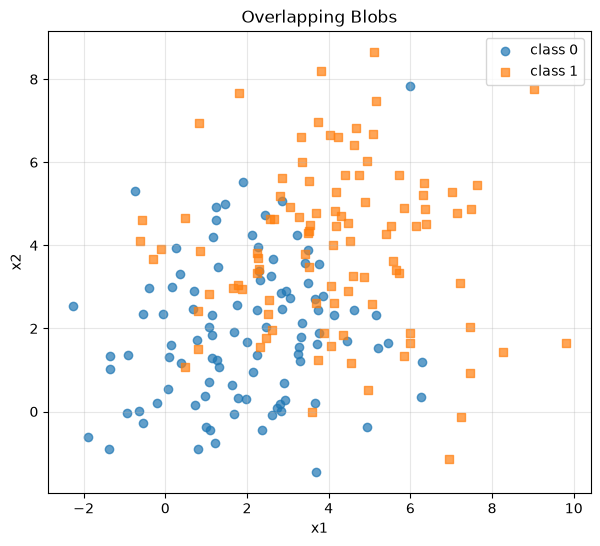

In [66]:
# Generates blobs of data for us to classify
rng = np.random.default_rng(42)

# Each line generates 100 rows with 2 features.
X0 = rng.normal(loc = [2, 2], scale = 2.0, size=(100,2)) # class 0
X1 = rng.normal(loc = [4, 4], scale = 2.0, size=(100,2)) # class 1

X  = np.vstack([X0, X1])

# Can just stack horizontally. Top half is class 0 and bottom half is class 1
y  = np.hstack([np.zeros(100), np.ones(100)]) 

plt.figure(figsize=(7, 6))
plt.scatter(X0[:, 0], X0[:, 1], c='tab:blue',   marker='o', alpha=0.7, label='class 0')
plt.scatter(X1[:, 0], X1[:, 1], c='tab:orange', marker='s', alpha=0.7, label='class 1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(alpha=0.3)
plt.title('Overlapping Blobs')
plt.show()

### GD Implementation


Results for GD
bias (w0)        -3.3093
w1                0.5218
w2                0.5969
cost              0.4660
--------------------------------------
              pred 0    pred 1
actual 0          74        26
actual 1          27        73
--------------------------------------
accuracy          0.7350
precision         0.7374
recall            0.7300
f1                0.7337


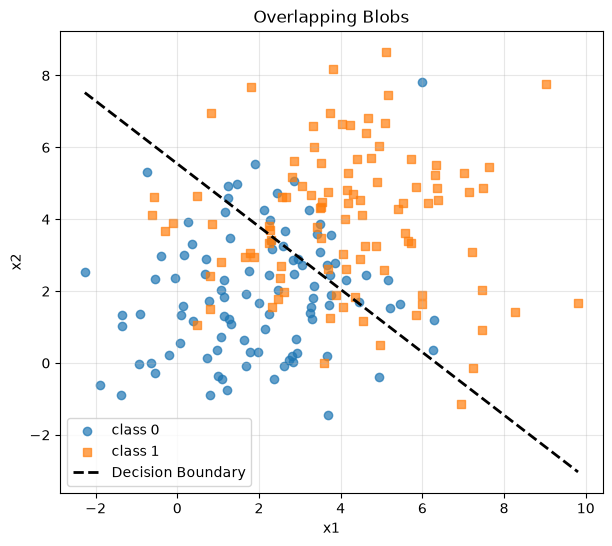

In [67]:
## Gradient Descent
Xb = add_bias(X)
theta, history = gradient_descent(Xb, y, n_iters=20000)
y_pred_gd = predict(Xb, theta)

print_report(y, y_pred_gd, theta, Xb, title="Results for GD")

# plotting the decision boundary
def boundary(X, theta):
    x1 = np.array([X[:, 0].min(), X[:, 0].max()])
    x2 = (-theta[0] - theta[1] * x1) / theta[2]

    return x1, x2

x1, x2 = boundary(X, theta)
plt.figure(figsize=(7, 6))
plt.scatter(X0[:, 0], X0[:, 1], c='tab:blue',   marker='o', alpha=0.7, label='class 0')
plt.scatter(X1[:, 0], X1[:, 1], c='tab:orange', marker='s', alpha=0.7, label='class 1')
plt.plot(x1, x2, 'k--', lw=2, label='Decision Boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(alpha=0.3)
plt.title('Overlapping Blobs')
plt.show()

### Sk Learn Implementation


Results for sklearn
bias (w0)        -3.2686
w1                0.5159
w2                0.5889
cost              0.4660
--------------------------------------
              pred 0    pred 1
actual 0          74        26
actual 1          27        73
--------------------------------------
accuracy          0.7350
precision         0.7374
recall            0.7300
f1                0.7337


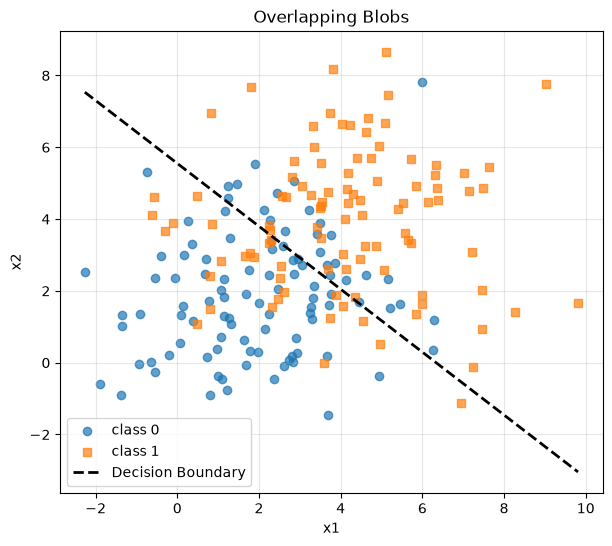

In [68]:
## Sk learn
model = LogisticRegression(max_iter=20000)
model.fit(X, y)

y_pred_sk = model.predict(X).astype(int)
sk_theta = np.concatenate([model.intercept_, model.coef_[0]])
print_report(y, y_pred_sk, sk_theta, Xb, title="Results for sklearn")

x1, x2 = boundary(X, sk_theta)
plt.figure(figsize=(7, 6))
plt.scatter(X0[:, 0], X0[:, 1], c='tab:blue',   marker='o', alpha=0.7, label='class 0')
plt.scatter(X1[:, 0], X1[:, 1], c='tab:orange', marker='s', alpha=0.7, label='class 1')
plt.plot(x1, x2, 'k--', lw=2, label='Decision Boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(alpha=0.3)
plt.title('Overlapping Blobs')
plt.show()
